# 36 - LSEG/Gemma-FinBERT capped hybrid alpha audit

**Question.** Does the single frozen capped hybrid identified by Notebooks
34-35 clear a direct after-cost cash-alpha interval, remain positive after a
static market/sector factor span, and avoid dependence on one company or
sector?

The candidate is fixed before this audit: immutable original-33 universe;
Gemma exact +/-1 events decide eligible dates and daily long/short counts;
FinBERT continuous strongest-event rank selects those names; each leg is
capacity-constrained by the same 25% maximum name weight; one open-to-open
interval; cash on ineligible dates; 10 bps per traded side; drifted weights,
after-cost NAV marking, and final liquidation. No rule or parameter is swept.

The **retrospective alpha gate** requires the five-session circular-block
interval for net return versus cash to exclude zero, two-sided p<0.05, the
already-frozen Notebook 35 timing gate, at least 60 active sessions, break-even
above charged cost, maximum name weight <=25%, and nonnegative net Sharpe in
both independently initialized halves. A separate **factor-alpha gate**
requires the HAC(5) intercept to exclude zero after spanning the equal-weight
original-33 market and ten independent sector-minus-market returns. Constant-
only and market-only fits are diagnostics. Company and sector leave-one-out
replays rebuild both the Gemma schedule and FinBERT ranks; they are quality
diagnostics, not additional alpha tests.

In [19]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    annotate_source,
    apply_house_style,
    label_line_ends,
    zero_line,
)
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260810
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
NOTEBOOK34_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/34_lseg_gemma_finbert_matched_count_substitution/manifest.json"
)
NOTEBOOK35_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/35_lseg_gemma_event_timing_circular_shift/manifest.json"
)
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
SPX_PATH = REPO_ROOT / "Data/derived/prices/lseg_sp500_20250620_20260710.csv"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen inputs, exact returns, and hybrid construction

Only aggregate firm-open scorer panels and prices are loaded; no licensed
headline text is read or persisted.

In [20]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
sector_by_symbol = {
    symbol: sector for sector, members in sector_members.items() for symbol in members
}
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate scorer rows")
if finbert["strongest_event"].isna().any():
    raise ValueError("FinBERT ranks must be complete")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != set(original_symbols):
    raise ValueError("expected 167 sessions and immutable original 33")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next open")

return_rows: list[OpenToOpenReturn] = []
return_matrix_rows: list[np.ndarray] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    returns = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    return_matrix_rows.append(returns.to_numpy(dtype=float))
    for symbol, value in returns.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_matrix = np.vstack(return_matrix_rows)
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price returns do not reproduce aggregate panel")


def rank_map(frame: pd.DataFrame, ordered_symbols: tuple[str, ...]) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(ordered_symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("rank map is incomplete or has the wrong universe")
    return result


def build_hybrid_targets(
    gemma_panel: pd.DataFrame,
    finbert_panel: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> tuple[tuple[TargetPortfolio, ...], pd.DataFrame]:
    _, audit = build_exact_extrema_targets(
        gemma_panel,
        single_name_cap=SINGLE_NAME_CAP,
    )
    ranks = rank_map(finbert_panel, ordered_symbols)
    targets: list[TargetPortfolio] = []
    for row in audit.itertuples(index=False):
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        ranked = ranks[pd.Timestamp(row.session_date)]
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid hybrid rank selection")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_long,
                SINGLE_NAME_CAP * n_short,
            )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        vector = np.array([weights[symbol] for symbol in ordered_symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("hybrid target violates exposure constraints")
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=1.0 if symbol in long_symbols else -1.0 if symbol in short_symbols else 0.0,
                volatility=None,
                raw_weight=weights[symbol],
                target_weight=weights[symbol],
                exclusion_reason=None,
            )
            for symbol in ordered_symbols
        )
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=positions,
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets), audit


hybrid_targets, hybrid_audit = build_hybrid_targets(gemma, finbert, symbols)
coverage = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": len(sector_members),
            "active_sessions": int(hybrid_audit["eligible"].sum()),
            "maximum_name_weight": SINGLE_NAME_CAP,
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage.T)

,0
sessions,167.000000
companies,33.000000
sectors,11.000000
active_sessions,70.000000
maximum_name_weight,0.250000
max_return_reproduction_error,0.000000


## Drift-aware path, direct cash inference, and cost sensitivity

In [21]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * np.sqrt(252)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


hybrid_daily = run_targets(hybrid_targets, return_rows, cost_bps=COST_BPS)
hybrid_result = pd.DataFrame([summarize(hybrid_daily, cost_bps=COST_BPS)])
notebook34 = json.loads(NOTEBOOK34_MANIFEST.read_text())
reference = (
    pd.DataFrame(notebook34["results"])
    .set_index(["scorer", "rule"])
    .loc[("finbert_rank_substitute", "capacity_capped")]
)
for metric in (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
):
    if not np.isclose(hybrid_result.loc[0, metric], reference[metric], atol=1e-10):
        raise RuntimeError(f"Notebook 34 reproduction failed for {metric}")

cash = hybrid_daily[["session_date"]].copy()
cash["net_return"] = 0.0
cash_inference = pd.DataFrame(
    [
        {
            "comparison": "capped_hybrid_minus_cash",
            **paired_block_bootstrap_difference(
                hybrid_daily,
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED,
            ),
        }
    ]
)

cost_rows = []
for cost in COST_GRID:
    daily = run_targets(hybrid_targets, return_rows, cost_bps=cost)
    cost_rows.append(summarize(daily, cost_bps=cost))
cost_curve = pd.DataFrame(cost_rows)
display(hybrid_result.T)
display(cash_inference.T)

,0
n_sessions,167.000000
active_sessions,70.000000
mean_gross,0.001127
mean_net,0.000680
sharpe_gross,3.699940
sharpe_net,2.271209
ann_vol_net,0.075473
total_return_gross,0.204584
total_return_net,0.118176
max_drawdown,-0.029025


,0
comparison,capped_hybrid_minus_cash
n_sessions,167
mean_difference,0.000680
ci_low,0.000041
ci_high,0.001337
p_two_sided,0.039000
block_length,5
replications,9999
seed,20260810


## Static market and sector-factor intercepts

The sector-spanning model uses the original-33 equal-weight market plus ten
sector-minus-market returns; omitting the alphabetically last sector removes
the single linear dependency while spanning all eleven sector portfolios.

In [22]:
factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
sector_names = tuple(sorted(sector_members))
for sector in sector_names:
    indices = [symbol_index[symbol] for symbol in sector_members[sector]]
    factor_panel[f"sector_{sector}"] = return_matrix[:, indices].mean(axis=1)
spread_columns = []
for sector in sector_names[:-1]:
    column = f"spread_{sector}"
    factor_panel[column] = (
        factor_panel[f"sector_{sector}"] - factor_panel["equal_weight_market"]
    )
    spread_columns.append(column)

regression = hybrid_daily[["session_date", "net_return"]].merge(
    factor_panel, on="session_date", validate="1:1"
)
model_specs = {
    "constant_only": [],
    "market_only": ["equal_weight_market"],
    "sector_spanning": ["equal_weight_market", *spread_columns],
}
factor_rows = []
for model_name, columns in model_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
        raise RuntimeError(f"factor design is rank deficient for {model_name}")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
        }
    )
factor_models = pd.DataFrame(factor_rows)
display(factor_models)

,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,constant_only,167,0,6.802202,0.406065,13.198338,2.084394,0.037124,0.000000,NaN
1,market_only,167,1,6.146365,0.349076,11.943654,2.077981,0.037711,0.017975,0.089833
2,sector_spanning,167,11,4.823245,-0.436483,10.082973,1.797315,0.072286,0.189726,0.140250


## Company and sector dependence

Every exclusion rebuilds Gemma eligibility/counts and FinBERT ranks before
using only the surviving companies' returns.

In [23]:
def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_gemma = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_finbert = finbert.loc[finbert["symbol"].isin(remaining)].copy()
    reduced_targets, _ = build_hybrid_targets(reduced_gemma, reduced_finbert, remaining)
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize(reduced_daily, cost_bps=COST_BPS)


company_rows = []
for removed_symbol in symbols:
    remaining = tuple(symbol for symbol in symbols if symbol != removed_symbol)
    company_rows.append({"removed_symbol": removed_symbol, **replay_subset(remaining)})
company_loo = pd.DataFrame(company_rows).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for removed_sector, removed_symbols in sector_members.items():
    removed = set(removed_symbols)
    remaining = tuple(symbol for symbol in symbols if symbol not in removed)
    sector_rows.append({"removed_sector": removed_sector, **replay_subset(remaining)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
        }
    ]
)
display(dependence.T)

,0
company_replays,33.000000
positive_company_replays,33.000000
minimum_company_loo_sharpe,0.767495
median_company_loo_sharpe,2.348638
sector_replays,11.000000
positive_sector_replays,11.000000
minimum_sector_loo_sharpe,0.579806
median_sector_loo_sharpe,1.910513


## Frozen gates

In [24]:
notebook35 = json.loads(NOTEBOOK35_MANIFEST.read_text())
timing_gate = bool(
    pd.DataFrame(notebook35["gates"])
    .set_index("rule")
    .loc["capacity_capped", "timing_gate"]
)
temporal34 = pd.DataFrame(notebook34["temporal"])
hybrid_halves = (
    temporal34.loc[
        temporal34["scorer"].eq("finbert_rank_substitute")
        & temporal34["rule"].eq("capacity_capped")
    ]
    .set_index("period")["sharpe_net"]
)
result = hybrid_result.iloc[0]
cash_row = cash_inference.iloc[0]
sector_factor = factor_models.set_index("model").loc["sector_spanning"]
retrospective_alpha_gate = bool(
    cash_row["ci_low"] > 0
    and cash_row["p_two_sided"] < 0.05
    and timing_gate
    and result["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and result["breakeven_bps_per_side"] > COST_BPS
    and SINGLE_NAME_CAP <= 0.25
    and hybrid_halves["first_half"] >= 0
    and hybrid_halves["second_half"] >= 0
)
factor_alpha_gate = bool(
    sector_factor["alpha_ci_low_bps_session"] > 0
    and sector_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_quality_gate = bool(
    dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
    and dependence.loc[0, "minimum_company_loo_sharpe"] > 0
    and dependence.loc[0, "minimum_sector_loo_sharpe"] > 0
)
gates = pd.DataFrame(
    [
        {
            "retrospective_alpha_gate": retrospective_alpha_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "dependence_quality_gate": dependence_quality_gate,
            "timing_gate_upstream": timing_gate,
            "cash_mean_bps_session": float(cash_row["mean_difference"] * 10_000),
            "cash_ci_low_bps_session": float(cash_row["ci_low"] * 10_000),
            "cash_ci_high_bps_session": float(cash_row["ci_high"] * 10_000),
            "cash_p_two_sided": float(cash_row["p_two_sided"]),
            "sector_factor_alpha_bps_session": float(sector_factor["alpha_bps_session"]),
            "sector_factor_ci_low_bps_session": float(
                sector_factor["alpha_ci_low_bps_session"]
            ),
            "sector_factor_ci_high_bps_session": float(
                sector_factor["alpha_ci_high_bps_session"]
            ),
            "sector_factor_p_two_sided": float(
                sector_factor["alpha_p_two_sided_hac5"]
            ),
            "first_half_net_sharpe": float(hybrid_halves["first_half"]),
            "second_half_net_sharpe": float(hybrid_halves["second_half"]),
            "breakeven_bps_per_side": float(result["breakeven_bps_per_side"]),
        }
    ]
)
display(gates.T)

,0
retrospective_alpha_gate,True
factor_alpha_gate,False
dependence_quality_gate,True
timing_gate_upstream,True
cash_mean_bps_session,6.802202
cash_ci_low_bps_session,0.414490
cash_ci_high_bps_session,13.370793
cash_p_two_sided,0.039000
sector_factor_alpha_bps_session,4.823245
sector_factor_ci_low_bps_session,-0.436483


## Figures

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_77482/3992242575.py:69: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  axes[0].set_xlim(dates.iloc[0], dates.iloc[-1] + pd.Timedelta(days=28))


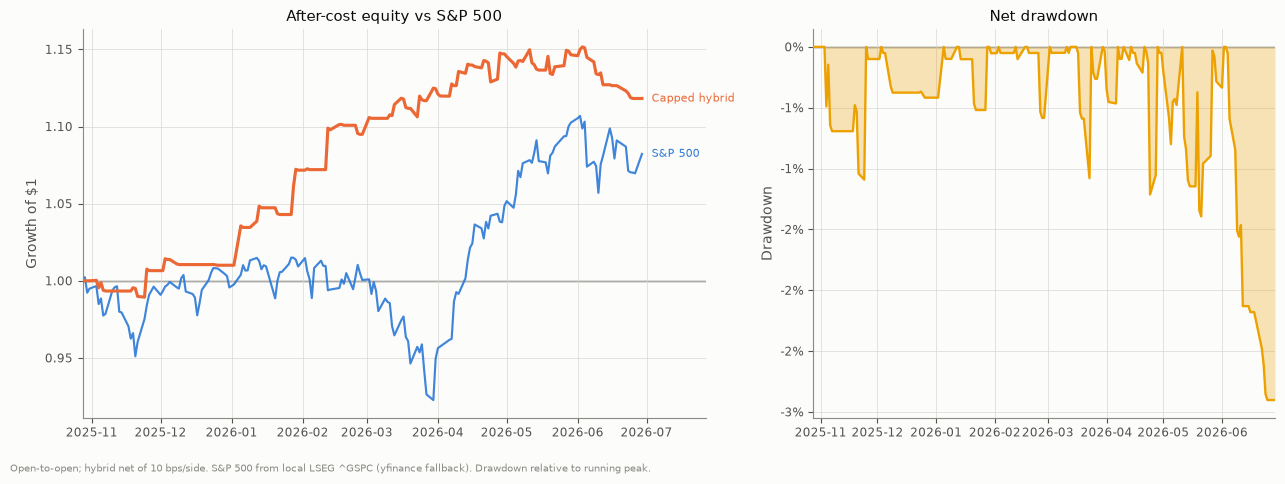

In [25]:
def load_spx_open_levels(start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    """S&P 500 daily levels for open-to-open benchmark returns.

    Prefer the local LSEG ^GSPC archive already used by Notebook 46; fall back
    to yfinance if that file is absent.
    """
    if SPX_PATH.exists():
        frame = pd.read_csv(SPX_PATH, parse_dates=["session_date"])
        levels = frame.set_index("session_date")["open"].astype(float).sort_index()
        return levels.loc[(levels.index >= start) & (levels.index <= end)]
    import yfinance as yf

    downloaded = yf.download(
        "^GSPC",
        start=(start - pd.Timedelta(days=5)).date().isoformat(),
        end=(end + pd.Timedelta(days=5)).date().isoformat(),
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=False,
        multi_level_index=False,
    )
    if downloaded is None or downloaded.empty:
        raise RuntimeError("yfinance returned no ^GSPC prices for the hybrid window")
    levels = downloaded["Open"].astype(float)
    levels.index = pd.to_datetime(levels.index).tz_localize(None).normalize()
    levels = levels.rename_axis("session_date").sort_index()
    return levels.loc[(levels.index >= start) & (levels.index <= end)]


plot_frame = hybrid_daily[["session_date", "return_end_date", "net_return"]].copy()
plot_frame["session_date"] = pd.to_datetime(plot_frame["session_date"])
plot_frame["return_end_date"] = pd.to_datetime(plot_frame["return_end_date"])
spx_open = load_spx_open_levels(
    plot_frame["session_date"].min(),
    plot_frame["return_end_date"].max(),
)
start_open = spx_open.reindex(plot_frame["session_date"]).to_numpy(dtype=float)
end_open = spx_open.reindex(plot_frame["return_end_date"]).to_numpy(dtype=float)
if np.isnan(start_open).any() or np.isnan(end_open).any():
    raise RuntimeError("S&P 500 opens missing for one or more hybrid sessions")
plot_frame["spx_ret_open_h1"] = end_open / start_open - 1.0

dates = plot_frame["return_end_date"]
equity = (1.0 + plot_frame["net_return"]).cumprod()
spx_equity = (1.0 + plot_frame["spx_ret_open_h1"]).cumprod()
drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity.to_numpy()])[1:] - 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), gridspec_kw={"width_ratios": [1.35, 1.0]})

axes[0].plot(
    dates,
    spx_equity,
    color=CATEGORICAL[0],
    lw=1.55,
    alpha=0.9,
    zorder=2,
)
axes[0].plot(
    dates,
    equity,
    color=CATEGORICAL[1],
    lw=2.25,
    zorder=3,
)
axes[0].axhline(1.0, color=INK["reference"], lw=1.0, zorder=1)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("After-cost equity vs S&P 500")
axes[0].set_xlim(dates.iloc[0], dates.iloc[-1] + pd.Timedelta(days=28))
label_line_ends(
    axes[0],
    [
        (dates.iloc[-1], float(spx_equity.iloc[-1]), "S&P 500", CATEGORICAL[0]),
        (dates.iloc[-1], float(equity.iloc[-1]), "Capped hybrid", CATEGORICAL[1]),
    ],
)

axes[1].fill_between(
    dates,
    drawdown,
    0.0,
    color=CATEGORICAL[3],
    alpha=0.28,
    lw=0,
    zorder=2,
)
axes[1].plot(dates, drawdown, color=CATEGORICAL[3], lw=1.7, zorder=3)
zero_line(axes[1])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{100 * value:.0f}%"))
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Net drawdown")
axes[1].set_xlim(dates.iloc[0], dates.iloc[-1])

for axis in axes:
    axis.tick_params(axis="x", labelsize=8.5)
    axis.tick_params(axis="y", labelsize=8.5)

fig.tight_layout()
annotate_source(
    fig,
    "Open-to-open; hybrid net of 10 bps/side. S&P 500 from local LSEG ^GSPC "
    "(yfinance fallback). Drawdown relative to running peak.",
)
fig.savefig(OUTPUT_DIR / "hybrid_equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()


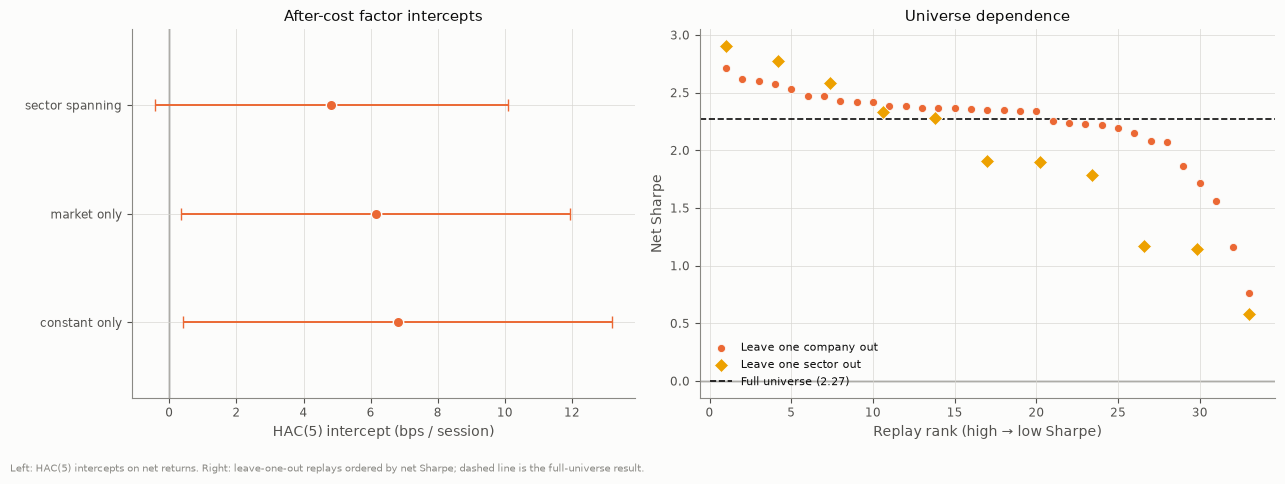

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), gridspec_kw={"width_ratios": [1.05, 1.2]})
models = factor_models.set_index("model").loc[list(model_specs)]
model_labels = [name.replace("_", " ") for name in models.index]
y = np.arange(len(models))

axes[0].errorbar(
    models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            models["alpha_bps_session"] - models["alpha_ci_low_bps_session"],
            models["alpha_ci_high_bps_session"] - models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    ecolor=CATEGORICAL[1],
    elinewidth=1.4,
    capsize=4.5,
    markersize=7.5,
    markeredgecolor=INK["surface"],
    markeredgewidth=1.0,
    zorder=3,
)
zero_line(axes[0], axis="x")
axes[0].set_yticks(y, model_labels)
axes[0].set_xlabel("HAC(5) intercept (bps / session)")
axes[0].set_title("After-cost factor intercepts")
axes[0].set_ylim(-0.7, len(models) - 0.3)

company_rank = (
    company_loo["sharpe_net"].sort_values(ascending=False).reset_index(drop=True)
)
sector_rank = (
    sector_loo["sharpe_net"].sort_values(ascending=False).reset_index(drop=True)
)
axes[1].scatter(
    np.arange(1, len(company_rank) + 1),
    company_rank,
    s=34,
    color=CATEGORICAL[1],
    edgecolors=INK["surface"],
    linewidths=0.6,
    zorder=3,
    label="Leave one company out",
)
axes[1].scatter(
    np.linspace(1, len(company_rank), len(sector_rank)),
    sector_rank,
    s=52,
    color=CATEGORICAL[3],
    marker="D",
    edgecolors=INK["surface"],
    linewidths=0.6,
    zorder=4,
    label="Leave one sector out",
)
axes[1].axhline(
    float(result["sharpe_net"]),
    color=INK["primary"],
    ls="--",
    lw=1.2,
    zorder=2,
    label=f"Full universe ({float(result['sharpe_net']):.2f})",
)
zero_line(axes[1])
axes[1].set_xlabel("Replay rank (high → low Sharpe)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Universe dependence")
axes[1].legend(loc="lower left", fontsize=8, frameon=False)

for axis in axes:
    axis.tick_params(axis="x", labelsize=8.5)
    axis.tick_params(axis="y", labelsize=8.5)

fig.tight_layout()
annotate_source(
    fig,
    "Left: HAC(5) intercepts on net returns. Right: leave-one-out replays "
    "ordered by net Sharpe; dashed line is the full-universe result.",
)
fig.savefig(OUTPUT_DIR / "factor_alpha_and_dependence.png", dpi=170, bbox_inches="tight")
plt.show()


## Persist aggregate outputs and decision

In [27]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
hybrid_audit.to_csv(OUTPUT_DIR / "hybrid_target_audit.csv", index=False)
hybrid_result.to_csv(OUTPUT_DIR / "hybrid_result.csv", index=False)
cash_inference.to_csv(OUTPUT_DIR / "cash_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
factor_panel.to_csv(OUTPUT_DIR / "factor_panel.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
hybrid_daily.to_parquet(OUTPUT_DIR / "capped_hybrid_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_FROZEN_CAPPED_HYBRID_ALPHA_AUDIT",
    "notebook": "36_lseg_gemma_finbert_hybrid_alpha_audit.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "notebook34_manifest": str(NOTEBOOK34_MANIFEST.relative_to(REPO_ROOT)),
        "notebook35_manifest": str(NOTEBOOK35_MANIFEST.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records"))[0],
    "specification": {
        "candidate": "Gemma exact-event schedule/counts plus FinBERT rank, 25%-capped",
        "universe": "immutable original 33",
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "cash_inference": f"{REPLICATIONS} five-session circular-block replications",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "leave_one_out": "rebuild Gemma schedule and FinBERT rank after every exclusion",
        "final_liquidation": True,
    },
    "result": json.loads(hybrid_result.to_json(orient="records"))[0],
    "cash_inference": json.loads(cash_inference.to_json(orient="records"))[0],
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebooks 34-35 and their opened outcomes directly motivated this audit",
        "the eight-month LSEG window is not an independent holdout",
        "the factor model controls static contemporaneous exposures, not dynamic causal channels",
        "the original-33 equal-weight sector factors are internal portfolio benchmarks",
        "block length five is inherited rather than selected here",
        "leave-one-out replays change the Gemma trigger schedule as well as ranks",
        "human validation of full-corpus Gemma labels remains open",
        "even a passing retrospective gate is not deployable alpha",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_FROZEN_CAPPED_HYBRID_ALPHA_AUDIT",
  "notebook": "36_lseg_gemma_finbert_hybrid_alpha_audit.ipynb",
  "git_commit_at_execution": "d4e20411413b58087cca961aab34a4ee9a83cdf2",
  "seed": 20260810,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "notebook34_manifest": "final_experiments/outputs/34_lseg_gemma_finbert_matched_count_substitution/manifest.json",
    "notebook35_manifest": "final_experiments/outputs/35_lseg_gemma_event_timing_circular_shift/manifest.json",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "sessions": 167,
    "companies": 33,
    "sectors": 11,
    "active_sessions": 70,
    "maximum_name_weight": 0.25,
    "max_return_r

## Decision

The single frozen capped hybrid clears the cash-relative retrospective gate.
At 10 bps per traded side it earns 6.802 bps per session after costs, with a
five-session circular-block interval of [0.414, 13.371] bps and a two-sided
p-value of 0.039. Gross/net Sharpe is 3.700/2.271, total net return is 11.82%,
maximum drawdown is -2.90%, and break-even cost is 25.24 bps per side. Both
independently initialised chronological halves are positive (3.364 and 0.972).

The dependence audit is also favourable: all 33 leave-one-company-out and all
11 leave-one-sector-out replays retain positive net Sharpe. Their minima are
0.767 and 0.580 respectively, after rebuilding both the Gemma event schedule
and the FinBERT ranks for each exclusion.

The stricter factor-alpha gate nevertheless fails. The HAC(5)
market-plus-sector-spread intercept is 4.823 bps per session, with a 95%
interval of [-0.436, 10.083] bps and p=0.072. Thus the data support a robust
same-window timing/selection candidate and reject a single-company or
single-sector explanation, but do not establish return unexplained by the
contemporaneous sector-spanning benchmark.

**Decision: retain as the leading LSEG/Gemma strategy candidate and the first
frozen retrospective cash-relative pass, but do not call it validated alpha or
deploy it.** Notebooks 34-35 directly motivated this opened-window audit, and
no independent post-freeze period exists. The next useful evidence is a fresh
time extension (or a separately frozen external cohort), not another parameter
search on these 167 sessions.